# Домашнє завдання: Прогнозування орендної плати за житло

## Мета завдання
Застосувати знання з лекції для побудови моделі лінійної регресії, що прогнозує орендну плату за житло в Індії. Ви пройдете весь цикл вирішення задачі машинного навчання: від дослідницького аналізу до оцінки якості моделі.

## Опис датасету
**House Rent Prediction Dataset** містить інформацію про 4700+ оголошень про оренду житла в Індії з такими параметрами:
- **BHK**: Кількість спалень, залів, кухонь
- **Rent**: Орендна плата (цільова змінна)
- **Size**: Площа в квадратних футах
- **Floor**: Поверх та загальна кількість поверхів
- **Area Type**: Тип розрахунку площі
- **Area Locality**: Район
- **City**: Місто
- **Furnishing Status**: Стан меблювання
- **Tenant Preferred**: Тип орендаря
- **Bathroom**: Кількість ванних кімнат
- **Point of Contact**: Контактна особа

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `House_Rent_Dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (включно з типами даних та кількістю значень)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('drive/MyDrive/Date_Analysis/data/House_Rent_Dataset.csv')

In [4]:
print(f'У датасеті {df.shape[0]} рядків та {df.shape[1]} колонок.')

У датасеті 4746 рядків та 12 колонок.


In [5]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


## Завдання 2: Дослідницький аналіз даних (EDA) (5 балів)

**Що потрібно зробити:**
1. **Аналіз пропущених значень.** Перевірте наявність і відсоток пропущених значень у кожній колонці
2. **Базова статистика.** Обчисліть базову статистику (середнє, квартилі, стандартне відхилення) для числових змінних.
3. **Аналіз цільової змінної.** Побудуйте гістограму розподілу цільової змінної (Rent)
4. **Робота з викидами.** Знайдіть та видаліть викиди в цільовій змінній (якщо є). Визначити викиди можна будь-яким зрозумілим для вас способом, як варіант - таким, що використовується в побудові box-plot (https://en.wikipedia.org/wiki/Box_plot#Example_with_outliers).
5. **Аналіз категоріальних змінних.** Виведіть кількість унікальних значень для кожної з категоріальних колонок.


In [7]:
# Перевіримо датасет на наявність пропущених даних:

missinng_data = df.isnull().sum()
missing_percent = (missinng_data / len(df)) * 100

missing_percent

,0
Posted On,0.0
BHK,0.0
Rent,0.0
Size,0.0
Floor,0.0
Area Type,0.0
Area Locality,0.0
City,0.0
Furnishing Status,0.0
Tenant Preferred,0.0


У датасеті не виявлено пропущених даних.

In [8]:
# Обчислимо для датасету базову статистику:

df_stat = df.select_dtypes('number').describe()
df_stat.round(2)

,BHK,Rent,Size,Bathroom
count,4746.00,4746.00,4746.00,4746.00
mean,2.08,34993.45,967.49,1.97
std,0.83,78106.41,634.20,0.88
min,1.00,1200.00,10.00,1.00
25%,2.00,10000.00,550.00,1.00
50%,2.00,16000.00,850.00,2.00
75%,3.00,33000.00,1200.00,2.00
max,6.00,3500000.00,8000.00,10.00


In [9]:
# Побудуємо гістограму розподілу орендної плати

fig = px.histogram(
    df,
    x='Rent',
    nbins=100,
    title='Розподіл цільової змінної (сума оренди)')

fig.update_layout(
    template='plotly_white',
    hovermode='x unified',
    height=500,
    xaxis_title='Орендна плата',
    yaxis_title='Кількість будинків'
)
fig.show()



In [10]:
# Перевіримо, чи є викиди в цільовій змінній:

Q1 = df['Rent'].quantile(0.25)
Q3 = df['Rent'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Rent'] < lower_bound) | (df['Rent'] > upper_bound)]

print(f'Кількість викидів: {len(outliers)}')

Кількість викидів: 520


In [11]:
# Видаляємо викиди:

df_clean = df[(df['Rent'] >= lower_bound) & (df['Rent'] <= upper_bound)].copy()
print(f'Розмір оновленого датасету без викидів: {df_clean.shape}')

Розмір оновленого датасету без викидів: (4226, 12)


In [12]:
#  Кількість унікальних значень для кожної з категоріальних колонок

nmb_unique = df_clean.select_dtypes('object').nunique()
nmb_unique

,0
Posted On,80
Floor,340
Area Type,3
Area Locality,1997
City,6
Furnishing Status,3
Tenant Preferred,3
Point of Contact,3



## Завдання 3: Аналіз кореляцій та взаємозв'язків (3 бали)

**Що потрібно зробити:**
1. Обчисліть матрицю кореляцій для числових змінних
2. Візуалізуйте кореляційну матрицю за допомогою heatmap
3. Побудуйте scatter plot між Size та Rent
4. Проаналізуйте взаємозв'язок між BHK та Rent за допомогою boxplot (який розподіл плати для різних значень BHK)


In [13]:
# Матриця кореляцій:

corr_matrix = df_clean.select_dtypes('number').corr()

In [14]:
# Візуалізація кореляцій

fig = px.imshow(
    corr_matrix,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    title='Кореляційна матриця числових змінних',
    labels=dict(color="Кореляція")
)
fig.update_layout(height=500)
fig.show()

In [15]:
# Scatter plot між Rent та Size

fig = px.scatter(
    df_clean,
    x='Rent',
    y='Size',
    title='Орендна плата vs площа житла',
    opacity=0.6
 )
fig.update_layout(height=600,
                template='plotly_white',
                xaxis_title='Орендна плата',
                yaxis_title='Площа житла')
fig.show()

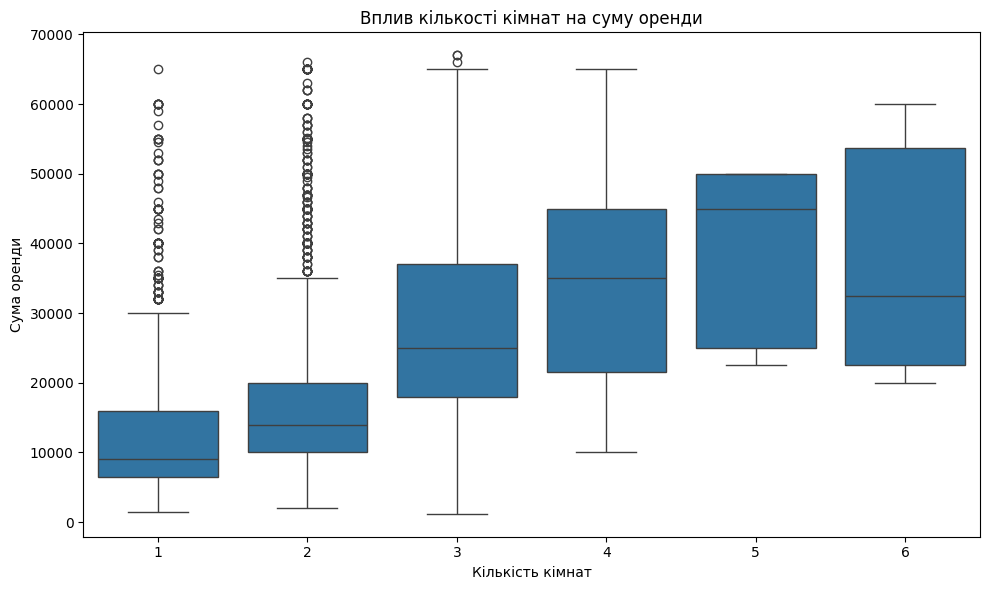

In [16]:
# Boxplot для BHK та Rent

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_clean,
    x='BHK',
    y='Rent'
)

plt.title('Вплив кількості кімнат на суму оренди')
plt.xlabel('Кількість кімнат')
plt.ylabel('Сума оренди')
plt.tight_layout()
plt.show()

На графіку можна прослідкувати, що для більшої кількості кімнат, відповідно зростає діапазон ціни на оренду, що логічно.

 Цікаво, що в 6-кімнатних квартирах медіана нижче ніж в 4-5 кімнатних. Можливо, у нас мало даних, або ж ціни дійсно нижчі, поганий район, старий будинок, або що.

 Також, бачимо, що для 1-2 кімнат є викиди, можна припустити, що дійсно є дороге житло з 1-2 кімнатами. Причиною цьому може бути дорогий район, новий якісний ремонт, новободова і тд.

## Завдання 4: Feature Engineering та підготовка даних (4 бали)

**Що потрібно зробити:**
1. Закодуйте категоріальні змінні за допомогою One-Hot Encoding. Пригадайте, що в лекції ми говорили щодо кодування кат. змінних з великої кількістю різних значень і як працювати з такими випадками. Ви можете закодувати не всі кат. змінні, а лише ті, що вважаєте за потрібні (скажімо ті, що мають відносно небагато різних значень).
2. **Опціонально (по 0.5 бала за кожну доцільну ознаку):** Додайте нові ознаки, обчислені на основі наявних даних, які б на ваш погляд були корисними для моделі
3. Виберіть ознаки для побудови моделі (виключіть непотрібні колонки). Виключити можна, наприклад, ті колонки, які мають категоріальний тип і забагато (більше 20) різних значень. Треба виключити хоча б 1 колонку.
4. Розділіть дані на ознаки (X) та цільову змінну (y)
5. Застосуйте стандартизацію до числових ознак


In [17]:
# Спочатку закодуємо категоріальні змінні з малою кількістю різних значень:

area_type_dum = pd.get_dummies(df_clean['Area Type'], prefix='area_Type')
city_dum = pd.get_dummies(df_clean['City'], prefix='city')
furnishing_dum = pd.get_dummies(df_clean['Furnishing Status'], prefix='furnishing_status')
tenant_pref_dum = pd.get_dummies(df_clean['Tenant Preferred'], prefix='tenant_preferred')

Далі закодуємо змінну Floor, так як у нас 340 варіантів значень, які може приймати ця змінна, візьмемо топ-10, а решта піде в категорію 'other'.

In [18]:
top_floors = df_clean['Floor'].value_counts().head(10).index
df_clean['floor_grouped'] = df_clean['Floor'].apply(
    lambda x: x if x in top_floors else 'other'
)

In [19]:
# Закодуємо категоріальну змінну Floor

floor_dum = pd.get_dummies(df_clean['floor_grouped'], prefix='floor')

In [20]:
#   Додамо закодовані колонки до основного датасету

df_clean = pd.concat([df_clean, area_type_dum, city_dum, furnishing_dum,
                      tenant_pref_dum, floor_dum], axis=1)

In [21]:
df_clean.columns

Index(['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type',
       'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Bathroom', 'Point of Contact', 'floor_grouped', 'area_Type_Built Area',
       'area_Type_Carpet Area', 'area_Type_Super Area', 'city_Bangalore',
       'city_Chennai', 'city_Delhi', 'city_Hyderabad', 'city_Kolkata',
       'city_Mumbai', 'furnishing_status_Furnished',
       'furnishing_status_Semi-Furnished', 'furnishing_status_Unfurnished',
       'tenant_preferred_Bachelors', 'tenant_preferred_Bachelors/Family',
       'tenant_preferred_Family', 'floor_1 out of 1', 'floor_1 out of 2',
       'floor_1 out of 3', 'floor_1 out of 4', 'floor_2 out of 3',
       'floor_2 out of 4', 'floor_3 out of 4', 'floor_Ground out of 1',
       'floor_Ground out of 2', 'floor_Ground out of 3', 'floor_other'],
      dtype='object')

In [22]:
# Обираємо ознаки

features = (df_clean[['BHK', 'Size', 'Bathroom']].columns.tolist() +
            area_type_dum.columns.tolist() + city_dum.columns.tolist() +
            furnishing_dum.columns.tolist() + tenant_pref_dum.columns.tolist() +
            floor_dum.columns.tolist())

In [23]:
# Розділяємо дані на X (ознаки) та y (цільову змінну)

X = df_clean[features]
y = df_clean['Rent']

print(f'Розмір X (ознак): {X.shape}')
print(f'Розмір y (цілі): {y.shape}')

Розмір X (ознак): (4226, 29)
Розмір y (цілі): (4226,)


In [24]:
# Застосуємо стандартизацію до числових ознак

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

In [25]:
X_scaled_df.head()

,BHK,Size,Bathroom,area_Type_Built Area,area_Type_Carpet Area,area_Type_Super Area,city_Bangalore,city_Chennai,city_Delhi,city_Hyderabad,...,floor_1 out of 2,floor_1 out of 3,floor_1 out of 4,floor_2 out of 3,floor_2 out of 4,floor_3 out of 4,floor_Ground out of 1,floor_Ground out of 2,floor_Ground out of 3,floor_other
0,0.052966,0.469859,0.272578,-0.02176,-0.878583,0.879429,-0.502144,-0.501774,-0.387614,-0.499926,...,-0.311597,-0.266888,-0.216372,-0.278902,-0.273943,-0.238806,-0.216971,3.348712,-0.226371,-0.813923
1,0.052966,-0.147778,-1.133910,-0.02176,-0.878583,0.879429,-0.502144,-0.501774,-0.387614,-0.499926,...,-0.311597,3.746885,-0.216372,-0.278902,-0.273943,-0.238806,-0.216971,-0.298622,-0.226371,-0.813923
2,0.052966,0.263980,-1.133910,-0.02176,-0.878583,0.879429,-0.502144,-0.501774,-0.387614,-0.499926,...,-0.311597,3.746885,-0.216372,-0.278902,-0.273943,-0.238806,-0.216971,-0.298622,-0.226371,-0.813923
3,0.052966,-0.147778,-1.133910,-0.02176,-0.878583,0.879429,-0.502144,-0.501774,-0.387614,-0.499926,...,3.209278,-0.266888,-0.216372,-0.278902,-0.273943,-0.238806,-0.216971,-0.298622,-0.226371,-0.813923
4,0.052966,-0.044839,-1.133910,-0.02176,1.138197,-1.137102,-0.502144,-0.501774,-0.387614,-0.499926,...,3.209278,-0.266888,-0.216372,-0.278902,-0.273943,-0.238806,-0.216971,-0.298622,-0.226371,-0.813923


## Завдання 5: Розділення даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на навчальну (80%) та тестову (20%) вибірки.
2. Створіть модель лінійної регресії.
3. Навчіть модель на навчальних даних.
4. Виведіть усі коефіцієнти моделі (ваги) та напишіть, які 2 ознаки найбільше впливають на прогноз.
5. Зробіть прогнози на тренувальній та тестовій вибірках.

In [26]:
# Розділимо дані на тренувальну та тестову вибірки

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y,
    test_size=0.2,
    random_state=42
)

In [27]:
# Створюємо модель лінійної регресії

from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [28]:
# Навчаємо модель на навчальних даних

model.fit(X_train, y_train)

LinearRegression()

In [29]:
# Виведемо ваги для кожної ознаки

for feature, weight in zip(model.feature_names_in_, model.coef_):
  print(f'{feature}: {weight:.2f}')

print(f'Зміщення (intercept):{model.intercept_:.2f}')

BHK: 2301.65
Size: 4418.76
Bathroom: 2102.83
area_Type_Built Area: 6.10
area_Type_Carpet Area: 732.76
area_Type_Super Area: -732.93
city_Bangalore: -956.38
city_Chennai: -1404.81
city_Delhi: 374.90
city_Hyderabad: -2248.50
city_Kolkata: -1615.73
city_Mumbai: 6429.08
furnishing_status_Furnished: 998.31
furnishing_status_Semi-Furnished: -56.83
furnishing_status_Unfurnished: -609.68
tenant_preferred_Bachelors: 433.47
tenant_preferred_Bachelors/Family: -78.66
tenant_preferred_Family: -449.82
floor_1 out of 1: -441.91
floor_1 out of 2: -388.82
floor_1 out of 3: -145.81
floor_1 out of 4: 20.04
floor_2 out of 3: 80.05
floor_2 out of 4: -35.06
floor_3 out of 4: -73.41
floor_Ground out of 1: -338.62
floor_Ground out of 2: -463.04
floor_Ground out of 3: -88.81
floor_other: 897.50
Зміщення (intercept):19323.44


Бачимо, що найбільше на прогноз впливає площа житла та розміщення житла в місті Мумбай.

In [30]:
# Робимо прогнози на тренувальній та тестовій вибірках

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Порівняння перших 10 прогнозів з реальністю

comparison = pd.DataFrame({
    'Реальна орендна плата': y_test.values[:10],
    'Прогнозована орендна плата': y_test_pred[:10].round(0),
    'Помилка': y_test.values[:10] - y_test_pred[:10].round(0)
})

print('Приклади прогнозів на тестовій вибірці:')
print(comparison)

Приклади прогнозів на тестовій вибірці:
   Реальна орендна плата  Прогнозована орендна плата  Помилка
0                  22000                     30968.0  -8968.0
1                   5000                      1527.0   3473.0
2                  37000                     37234.0   -234.0
3                   8000                      3786.0   4214.0
4                  15000                     14898.0    102.0
5                  20000                     26074.0  -6074.0
6                   8500                     14188.0  -5688.0
7                   7000                      3016.0   3984.0
8                   3000                       704.0   2296.0
9                   8000                      6529.0   1471.0


## Завдання 6: Оцінка якості моделі (2 бали)

**Що потрібно зробити:**
1. Обчисліть MAE, RMSE та R² для навчальної та тестової вибірок
2. Порівняйте метрики та зробіть висновок про якість моделі
3. Проаналізуйте і дайте висновок, чи є ознаки перенавчання або недонавчання (**Нагадування**: перенавчання - коли модель дуже добре працює на тренувальних даних, але погано на тестових; недонавчання - коли модель погано працює навіть на тренувальних даних)
4. Побудуйте графік розсіювання "реальні vs прогнозовані значення" та зробіть висновок про якість моделі


In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [32]:
# Обчислимо метрики для тестової вибірки

mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_pred)

print('Метрики якості моделі (тестова вибірка):')
print(f'MAE: {mae_test:.2f}')
print(f'RMSE: {rmse_test:.2f}')
print(f'R²: {r2_test:.3f}')


# Обчислимо метрики для навчальної вибірки

mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

print('\nМетрики якості моделі (тренувальна вибірка):')
print(f'MAE: {mae_train:.2f}')
print(f'RMSE: {rmse_train:.2f}')
print(f'R²: {r2_train:.3f}')

Метрики якості моделі (тестова вибірка):
MAE: 5830.33
RMSE: 8115.74
R²: 0.656

Метрики якості моделі (тренувальна вибірка):
MAE: 5896.26
RMSE: 8148.81
R²: 0.652


По обчисленим метрикам робимо висновок, що модель працює приблизно однаково на навчальній та тестовій вибірці, це свідчить про те, що не було перенавчання, тобто, модель не завчила дані, а дійсно навчилась непогано прогнозувати оренду і показала це на тестовій вибірці.

Коефіцієнт детермінації свідчить про те, що ми отримали непогану якість моделі (модель показує приблизно 65 % варіації в даних).

In [33]:
# Побудуємо графік розсіювання "реальні vs прогнозовані значення"

fig = px.scatter(
    x=y_test,
    y=y_test_pred,
    title='Реальні vs Прогнозовані значення орендної плати (тестова вибірка)',
    opacity=0.6
)

# Додаємо ідеальну лінію (де прогноз = реальність)
max_val = max(y_test.max(), y_test_pred.max())
fig.add_trace(
    go.Scatter(
        x=[0, max_val],
        y=[0, max_val],
        mode='lines',
        name='Ідеальний прогноз',
        line=dict(color='red', dash='dash')
    )
)
fig.update_layout(height=600,
                template='plotly_white',
                xaxis_title='Реальні значення орендної плати',
                yaxis_title='Прогнозовані значення орендної плати')
fig.show()

У цілому бачимо, що модель працює непогано, але неідеально, іноді переоцінює значення орендної плати, а іноді недооцінює, але ми вже маємо досить непогані результати.

## Завдання 7: Аналіз помилок (4 бали)

**Що потрібно зробити:**
1. Обчисліть помилки (residuals = реальні - прогнозовані значення)
2. Побудуйте гістограму розподілу помилок
3. Створіть scatter plot помилок відносно величини прогнозованих значень. Чи росте помилка з ростом прогнозованого значення?
4. Знайдіть 5 прогнозів з найбільшими помилками
5. Проаналізуйте, на яких типах житла модель помиляється найбільше. Типи можна розрізняти за кількістю кімнат чи містом, наприклад.
6. Подумайте і напишіть, які наступні кроки ви б зробили, аби поліпшити якість моделі. Опціонально можна їх зробити і ми перевіримо :)

In [34]:
# Обчислимо помилки
residuals = y_test - y_test_pred

In [35]:
# Побудуємо гістограму помилок

fig = px.histogram(
    x=residuals,
    nbins=50,
    title='Розподіл помилок прогнозування',
    color_discrete_sequence=['#e74c3c']
)

fig.add_vline(x=0, line_dash="dash", line_color="black", annotation_text="Ідеальний прогноз")

fig.update_layout(
    template='plotly_white',
    hovermode='x unified',
    height=500,
    xaxis_title='Помилка (реальні - прогнозовані)',
    yaxis_title='Кількість'
)
fig.show()

In [36]:
# Побудуємо scatter plot помилок відносно величини прогнозованих значень

fig = px.scatter(
    x=y_test_pred,
    y=residuals,
    title='Прогнозовані значення vs Помилки',
    opacity=0.6
)

# Додаємо горизонтальну лінію на 0
fig.add_hline(y=0, line_dash="dash", line_color="red", annotation_text="Без помилки")

fig.update_layout(height=600,
                template='plotly_white',
                xaxis_title='Прогнозовані значення',
                yaxis_title='Помилка')
fig.show()

Для прогнозованих значень до 20-30 К помилка менша, тобто, прогнози більш стабільні. А для прогнозованих значень більше 30 К помилка зростає. Можна зробити висновок, що модель погано працює для великих значень оренди.

In [37]:
# Знайдемо 5 прогнозів з найбільшими помилками

errors_df = pd.DataFrame({
    'real': y_test.values,
    'predicted': y_test_pred.round(2),
    'error': np.abs(residuals).round(2)
})

top_errors = errors_df.nlargest(5, 'error')
print('Оголошення з найбільшими помилками прогнозування:')
print(top_errors)

Оголошення з найбільшими помилками прогнозування:
       real  predicted     error
3520  65000   29484.32  35515.68
852    8000   40765.74  32765.74
549    8000   38321.08  30321.08
809   60000   30765.86  29234.14
904    8000   36284.42  28284.42


In [38]:
# Подивимось ближче на дані не модель помилилась найбільше

df.loc[[3520, 852, 549, 809, 904]]

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
3520,2022-07-10,3,65000,1444,11 out of 14,Super Area,Nungambakkam,Chennai,Semi-Furnished,Bachelors,3,Contact Agent
852,2022-05-06,2,8000,890,4 out of 4,Carpet Area,new panvel,Mumbai,Unfurnished,Bachelors/Family,2,Contact Owner
549,2022-06-02,2,8000,650,Upper Basement out of 9,Carpet Area,"Nakoda Heights, Nalasopara",Mumbai,Semi-Furnished,Family,2,Contact Agent
809,2022-06-30,1,60000,455,18 out of 22,Carpet Area,"Sugee Sadan, Dadar West",Mumbai,Unfurnished,Bachelors/Family,1,Contact Agent
904,2022-06-20,2,8000,550,3 out of 9,Carpet Area,"Nakoda Heights, Nalasopara",Mumbai,Unfurnished,Family,2,Contact Agent


5 із 6 оголошень з міста Мумбаї та має один area type. Але при цьому модель не враховує район міста, так як ми не додавали цю колонку в аналіз.

Ми не включали колонку Area Locality через велику кількість різних значень, а вона має важливе значення у ціноутворенні. Можливо, варто подумати над іншим способом її кодування та спробувати перенавчити модель враховуючи і ці дані.

Ще можна було б по іншому закодувати колонку Floor, наприклад, розділити її на дві колонки, поверх на якому знаходиться помешкання та скільки поверхів у будівлі в цілому.

Також, можна спробувати навчити модель на іншому методі.